In [1]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))
# print(f"Root path set to: {root_path}")
from eval_agent.user_agent.graph.user_agent_graph import build_graph 

Dataset path or embeddings path is not set. Please check the .env configuration.


c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\functions\query_decomposer.py:37: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.query_analyzer = LLMChain(llm=llm, prompt=self.prompt_builder, verbose=False)


In [2]:
llm = os.getenv("LLM_MODEL")  # e.g., "gpt-4o"
provider = os.getenv("LLM_PROVIDER")  # e.g., "openai"
memory = False # True if it is the experiment of the agent with memory, False if it is the experiment of the agent without memory
database = os.getenv("EXPERIMENT_NAME")
print(f"Running evaluation for LLM: {llm}, Provider: {provider}, Memory: {memory}, Database: {database}")

# Load the experiment dataset
json_file = f'../dataset_generation/dialogue_dataset/{database}_dialogue_dataset.json'
with open(json_file, 'r', encoding='utf-8') as f:
    experiments = json.load(f)


# Build the evaluation graph with the specified memory and environment
eval_graph = build_graph(text_to_sql_agent_memory=memory, env="tec")

experiment_memory = "memory" if memory else "agent_without_memory"
# Defines the name of the file where the results will be saved
evals_filename = f'{llm}-{experiment_memory}-{database}-eval.json'

# If the file already exists, load the experiments already evaluated
if os.path.exists(evals_filename):
    with open(evals_filename, 'r', encoding='utf-8') as f:
        evals = json.load(f)
else:
    evals = []

# Current template configuration (add details of the template used here)
processed_ids = {exp["experiment_id"] for exp in evals}

# Informations to Graph State
model_version = f"{provider}-{llm}"

experiment_type = f"text2sql_evaluation_{experiment_memory}"


Running evaluation for LLM: gpt-4o, Provider: azure, Memory: False, Database: mondial


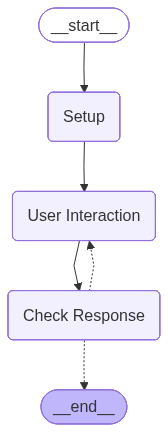

In [3]:
from IPython.display import Image, display


try:
    display(Image(eval_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [4]:
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]
    try: 
        # Se o experimento já foi avaliado, pula para o próximo
    
        if exp_id in processed_ids:
            print(f"Pulando experimento {exp_id} já processado.")
            continue

        print(f"Processando experimento {exp_id}...")

        config =  {"recursion_limit": 50}
        # Invoca a avaliação com as configurações estendidas
        eval_result = eval_graph.invoke({
            "experiment": experiment,
            "max_retries": 2,
            "debug_mode": True,
            "model_version": model_version,
            "experiment_type": experiment_type,
           
        }, config=config)

        print("Experimento avaliado:\n", eval_result["experiment_eval"])

        # Adiciona o resultado da avaliação junto com o ID do experimento e configuração
        evals.append({
            "experiment_id": exp_id,
            "experiment_config": eval_result.get("experiment_config", {
                "max_retries": 2,
                "model_version": model_version,
                "timestamp": datetime.now().isoformat(),
                "experiment_type": experiment_type
            }),
            "experiment_eval": eval_result["experiment_eval"]
        })

        # Atualiza o arquivo salvando o resultado atual
        with open(evals_filename, 'w', encoding='utf-8') as f:
            json.dump(evals, f, indent=4)
    except Exception as e:
        print(f"Erro ao processar experimento {exp_id}: {e}")


Processando experimento 1...
[NODE] Setup Node entered.
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  Can you list the airports along with their cities and countries?


c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "List all airports along with their cities and countries.",
    "schema_linking": ["airport"],
    "answer": "There are numerous airports listed along with their respective cities and countries. For example:\n1. Tancredo Neves Intl in Belo Horizonte, Brazil (BR)\n2. Marechal Cunha Machado Intl in São Luís, Brazil (BR)\n3. Amarais Airport in Campinas, Brazil (BR)\n4. Viracopos in Campinas, Brazil (BR)\n5. Santa Maria in Aracaju, Brazil (BR)\n...and many more. There are a total of 1318 entries.",
    "sql": "SELECT a.name AS airport_name, a.city AS city_name, a.country AS country_code FROM mondial_gpt.airport a"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "List all airports along with their cities and countries.",
    "schema_linking": ["airport"],
    "answer": "There are numerous airports listed along with their respective cities and countries. For 

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


True cols: Index(['NAME', 'CITY', 'COUNTRY'], dtype='object')
Adj. True cols: Index(['NAME', 'CITY', 'COUNTRY'], dtype='object')
Predicted cols: Index(['AIRPORT_NAME', 'CITY_NAME', 'COUNTRY_CODE'], dtype='object')
Adj. Predicted cols: Index(['AIRPORT_NAME', 'CITY_NAME', 'COUNTRY_CODE'], dtype='object')
[INFO] A avaliação para esse turno foi:  {'interaction_id': 1, 'original_intent': 'List the airports along with their cities and countries.', 'total_retries_needed': 0, 'success_without_retry': True, 'turns': [{'user_query': 'Can you list the airports along with their cities and countries?', 'agent_reply': 'There are numerous airports listed along with their respective cities and countries. For example:\n1. Tancredo Neves Intl in Belo Horizonte, Brazil (BR)\n2. Marechal Cunha Machado Intl in São Luís, Brazil (BR)\n3. Amarais Airport in Campinas, Brazil (BR)\n4. Viracopos in Campinas, Brazil (BR)\n5. Santa Maria in Aracaju, Brazil (BR)\n...and many more. There are a total of 1318 entries.

...

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "Provide the names of mountains in the province named Kerala.",
    "schema_linking": ["MONDIAL_GEO_MOUNTAIN", "MONDIAL_MOUNTAIN"],
    "answer": "The mountain in the province named Kerala is Anamudi.",
    "sql": "SELECT m.name FROM mondial_gpt.geo_mountain gm JOIN mondial_gpt.mountain m ON gm.mountain = m.name WHERE LOWER(gm.province) = LOWER('Kerala')"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Provide the names of mountains in the province named Kerala.",
    "schema_linking": ["MONDIAL_GEO_MOUNTAIN", "MONDIAL_MOUNTAIN"],
    "answer": "The mountain in the province named Kerala is Anamudi.",
    "sql": "SELECT m.name FROM mondial_gpt.geo_mountain gm JOIN mondial_gpt.mountain m ON gm.mountain = m.name WHERE LOWER(gm.province) = LOWER('Kerala')"
}.

[INFO] Avaliando o resultado: {'input': 'Provide the names of mountains in the province named Ker

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "feedback",
    "schema_linking": "",
    "answer": "Could you clarify the name of the province you are referring to, or provide additional context? This will help me provide the correct information.",
    "sql": ""
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "feedback",
    "schema_linking": "",
    "answer": "Could you clarify the name of the province you are referring to, or provide additional context? This will help me provide the correct information.",
    "sql": ""
}.

[INFO] Avaliando o resultado: {'input': 'feedback', 'schema_linking': '', 'answer': 'Could you clarify the name of the province you are referring to, or provide additional context? This will help me provide the correct information.', 'sql': ''}.

[AI as JUDGE] Judging if a feedback is needed for the last message in chat history.
[AI as JUDGE] Result: True.
[Schema Linking Recall

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
